In [43]:
import matplotlib.pyplot as plt




In [15]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("news.xlsx", low_memory=False)


print("Columns:\n", df.columns)
df.head()


Columns:
 Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='object')


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [21]:
import pandas as pd

df = pd.read_csv("news.xlsx", low_memory=False)
df.head()


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [22]:
import pandas as pd

# Load your dataset (already confirmed CSV)
df = pd.read_csv("news.xlsx", low_memory=False)

print("Shape:", df.shape)
df.head()


Shape: (1407328, 6)


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [23]:
df["headline_length"] = df["headline"].astype(str).str.len()

print(df["headline_length"].describe())


count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64


In [24]:
publisher_counts = df["publisher"].value_counts()

print("Top publishers:")
print(publisher_counts.head(10))


Top publishers:
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


In [25]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("Date range:", df["date"].min(), "→", df["date"].max())

articles_per_day = df.groupby(df["date"].dt.date).size()

articles_per_day.head()


Date range: 2011-04-27 21:01:48-04:00 → 2020-06-11 17:12:35-04:00


date
2011-04-27    1
2011-04-28    2
2011-04-29    2
2011-04-30    1
2011-05-01    1
dtype: int64

In [26]:
from collections import Counter
import re

# Combine all headlines
all_text = " ".join(df["headline"].astype(str)).lower()

# Remove punctuation
tokens = re.findall(r"[a-zA-Z]+", all_text)

word_freq = Counter(tokens)

print("Most common words:")
word_freq.most_common(20)


Most common words:


[('to', 404151),
 ('of', 270984),
 ('on', 245976),
 ('s', 240285),
 ('for', 239920),
 ('m', 223832),
 ('in', 223585),
 ('the', 213326),
 ('vs', 162126),
 ('stocks', 161776),
 ('q', 158581),
 ('est', 140650),
 ('eps', 128917),
 ('from', 120807),
 ('market', 120560),
 ('shares', 114315),
 ('and', 113931),
 ('reports', 108711),
 ('update', 91723),
 ('earnings', 87399)]

In [27]:
articles_per_month = df.groupby(df["date"].dt.to_period("M")).size()

print(articles_per_month.head())


date
2011-04      6
2011-05     78
2011-06     96
2011-07    137
2011-08    149
Freq: M, dtype: int64


C:\Users\Kisanet\AppData\Local\Temp\ipykernel_20096\1167745973.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  articles_per_month = df.groupby(df["date"].dt.to_period("M")).size()


In [28]:

df["hour"] = df["date"].dt.hour
df["hour"].value_counts().sort_index()



hour
0.0       67
1.0       14
2.0       57
3.0       93
4.0     1469
5.0     1829
6.0     2476
7.0     5033
8.0     5527
9.0     5965
10.0    7669
11.0    5701
12.0    5732
13.0    2710
14.0    2075
15.0    1612
16.0    3939
17.0    2800
18.0     704
19.0     227
20.0     131
21.0      82
22.0      48
23.0      27
Name: count, dtype: int64

In [29]:
df["publisher_domain"] = df["publisher"].astype(str).str.extract(r"@(.+)")
df["publisher_domain"].value_counts().head(10)


publisher_domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64

In [30]:
articles_per_day = df.groupby(df["date"].dt.date).size()

print(articles_per_day.head())
print("\nDaily count stats:")
print(articles_per_day.describe())


date
2011-04-27    1
2011-04-28    2
2011-04-29    2
2011-04-30    1
2011-05-01    1
dtype: int64

Daily count stats:
count    2528.000000
mean       22.146756
std        68.144109
min         1.000000
25%         3.000000
50%         9.000000
75%        17.000000
max       973.000000
dtype: float64


In [31]:
df["date"].iloc[0]


Timestamp('2020-06-05 10:30:54-0400', tz='UTC-04:00')

In [32]:
# Extract hour of publishing
df["hour"] = df["date"].dt.hour

# Count articles published each hour
hourly_distribution = df["hour"].value_counts().sort_index()

hourly_distribution


hour
0.0       67
1.0       14
2.0       57
3.0       93
4.0     1469
5.0     1829
6.0     2476
7.0     5033
8.0     5527
9.0     5965
10.0    7669
11.0    5701
12.0    5732
13.0    2710
14.0    2075
15.0    1612
16.0    3939
17.0    2800
18.0     704
19.0     227
20.0     131
21.0      82
22.0      48
23.0      27
Name: count, dtype: int64

In [33]:
publisher_counts = df["publisher"].value_counts()

publisher_counts.head(10)


publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

In [34]:
import re

df["publisher_domain"] = df["publisher"].apply(
    lambda x: re.findall(r"@([\w\.-]+)", str(x))[0] if "@" in str(x) else None
)

df["publisher_domain"].value_counts().head(10)


publisher_domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64

In [35]:
publisher_daily = df.groupby([df["date"].dt.date, "publisher"]).size().unstack(fill_value=0)

publisher_daily.head()


publisher,ETF Professor,Sam Subramanian,Theo Kratz,Benzinga Staff,Craig Jones,Gary Cassady,BenzingaStaffT,BenzingaStaffB,Jonathan Chen,MicroCapital,...,The Cannabis Investor,Benzinga Newsdesk,Tom Meilleur,AARP,Natan Ponieman,Drew Levine,Neal Hamilton,Sumit Mehta,The Fresh Toast,Joseph Benjamin XIII
date,,,,,,,,,,,,,,,,,,,,,
2011-04-27,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-04-28,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-04-29,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-04-30,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-05-01,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [36]:
import re
from collections import Counter

# Convert headlines to lowercase
df["clean_headline"] = df["headline"].astype(str).str.lower()

# Remove punctuation
df["clean_headline"] = df["clean_headline"].str.replace(r"[^\w\s]", "", regex=True)

# Split into words
all_words = df["clean_headline"].str.split().explode()

# Remove very common stopwords
stopwords = {"the","a","an","and","to","for","of","in","on","at","by","with","from","is","are"}

filtered_words = all_words[~all_words.isin(stopwords)]

# Count keyword frequency
keyword_counts = Counter(filtered_words)

keyword_counts.most_common(20)


[('vs', 162061),
 ('stocks', 161868),
 ('est', 140578),
 ('eps', 128910),
 ('shares', 114182),
 ('reports', 108705),
 ('update', 91680),
 ('market', 90879),
 ('earnings', 87185),
 ('sales', 79524),
 ('top', 78648),
 ('pt', 73043),
 ('up', 71364),
 ('announces', 66528),
 ('price', 64231),
 ('buy', 64059),
 ('downgrades', 61942),
 ('trading', 61156),
 ('benzingas', 57985),
 ('raises', 57798)]

In [37]:
articles_per_day = df.groupby(df["date"].dt.date).size()

articles_per_day.head()


date
2011-04-27    1
2011-04-28    2
2011-04-29    2
2011-04-30    1
2011-05-01    1
dtype: int64

In [38]:
import numpy as np

mean_val = articles_per_day.mean()
std_val = articles_per_day.std()

threshold = mean_val + 2*std_val

spikes = articles_per_day[articles_per_day > threshold]

spikes


date
2020-02-27    275
2020-02-28    381
2020-03-06    281
2020-03-11    282
2020-03-12    973
2020-03-19    629
2020-03-23    375
2020-03-24    160
2020-04-09    164
2020-04-13    184
2020-04-15    186
2020-04-16    199
2020-04-17    194
2020-04-20    180
2020-04-21    233
2020-04-22    245
2020-04-23    265
2020-04-24    246
2020-04-27    283
2020-04-28    317
2020-04-29    449
2020-04-30    488
2020-05-01    385
2020-05-04    347
2020-05-05    478
2020-05-06    531
2020-05-07    749
2020-05-08    508
2020-05-11    485
2020-05-12    387
2020-05-13    549
2020-05-14    536
2020-05-15    322
2020-05-18    547
2020-05-19    332
2020-05-20    461
2020-05-21    333
2020-05-22    286
2020-05-26    628
2020-05-27    492
2020-05-28    465
2020-05-29    309
2020-06-01    484
2020-06-02    361
2020-06-03    720
2020-06-04    538
2020-06-05    932
2020-06-08    765
2020-06-09    804
2020-06-10    806
2020-06-11    544
dtype: int64

In [39]:
spike_date = spikes.index[0]   # choose first spike
df[df["date"].dt.date == spike_date]["headline"].head(20)


5742      AAON shares are trading higher after the compa...
5743      AAON Q4 EPS $0.33 Beats $0.29 Estimate, Sales ...
10041     Ambev shares are trading lower after peer Anhe...
31886     Aegion Yesterday Reported Q4 EPS $0.39 Misses ...
47417              Stocks That Hit 52-Week Lows On Thursday
50615              Stocks That Hit 52-Week Lows On Thursday
57876              Stocks That Hit 52-Week Lows On Thursday
58088     Piper Sandler Maintains Neutral on Alexander &...
58233     Alamo Group Q4 EPS $1.32 Misses $1.51 Estimate...
63536              Stocks That Hit 52-Week Lows On Thursday
64711     Altair Engineering Sees Q1 Adj. EBITDA $20M-$2...
64712     Altair Engineering Q4 EPS $0.09 Beats $0.05 Es...
66367              Stocks That Hit 52-Week Lows On Thursday
72592     Amphastar Pharma Reports Receives FDA Approval...
75453              Stocks That Hit 52-Week Lows On Thursday
77376              Stocks That Hit 52-Week Lows On Thursday
83431              Stocks That Hit 52-We

In [40]:
# ============================================
# 4. PUBLISHER ANALYSIS
# ============================================

print("\nTop 20 Publishers (Most Articles):")
publisher_counts = df['publisher'].value_counts().head(20)
display(publisher_counts)

# Plot top publishers
publisher_counts.plot(kind='bar', figsize=(10,5))
plt.title("Top 20 Most Active Publishers")
plt.xlabel("Publisher")
plt.ylabel("Number of Articles")
plt.show()


# ============================================
# 5. DOMAIN EXTRACTION (if publisher is email-like)
# ============================================

import re

def extract_domain(text):
    match = re.search(r"@([\w\.-]+)", str(text))
    return match.group(1) if match else None

df["publisher_domain"] = df["publisher"].apply(extract_domain)

print("\nSample extracted domains:")
print(df["publisher_domain"].dropna().head(10))

# Count domains
domain_counts = df["publisher_domain"].value_counts().head(20)

print("\nTop 20 Publisher Domains:")
display(domain_counts)

# Plot domains
domain_counts.plot(kind='bar', figsize=(10,5))
plt.title("Top 20 Publisher Email Domains")
plt.xlabel("Domain")
plt.ylabel("Count")
plt.show()



Top 20 Publishers (Most Articles):


publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Allie Wickman         18317
Shanthi Rexaline      16640
Craig Jones           16221
Wayne Duggan          12897
Nelson Hem            12590
Name: count, dtype: int64

ImportError: matplotlib is required for plotting when the default backend "matplotlib" is selected.

Articles per day:


date
2011-04-27    1
2011-04-28    2
2011-04-29    2
2011-04-30    1
2011-05-01    1
dtype: int64

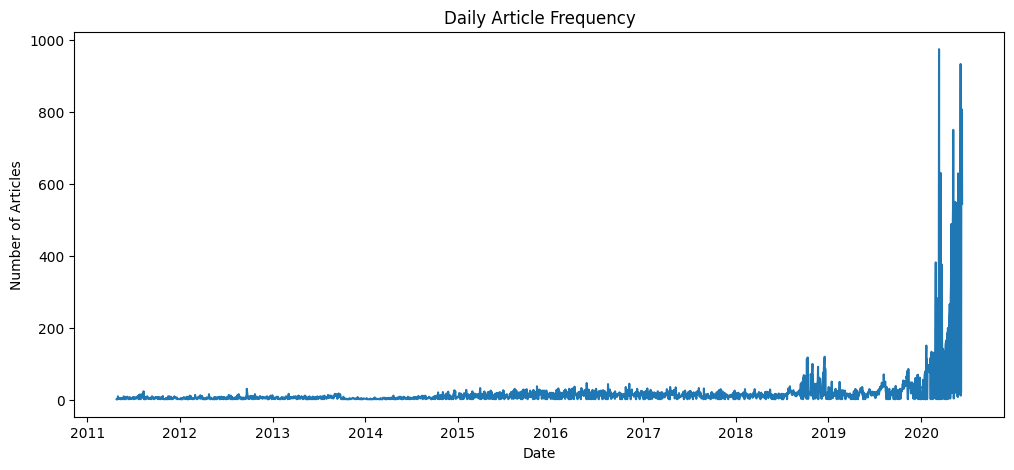

In [44]:
# --- TIME SERIES: ARTICLES PER DAY ---
articles_per_day = df.groupby(df["date"].dt.date).size()

print("Articles per day:")
display(articles_per_day.head())

# Plot daily article volume
articles_per_day.plot(figsize=(12,5))
plt.title("Daily Article Frequency")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.show()


In [42]:
# --- TEXT ANALYSIS: SIMPLE KEYWORD EXTRACTION ---
import re
from collections import Counter

# combine all headlines into one string
all_text = " ".join(df["headline"].astype(str)).lower()

# clean punctuation
all_text = re.sub(r"[^a-zA-Z0-9\s]", "", all_text)

# split words
words = all_text.split()

# remove common stopwords
stopwords = {
    "the","and","for","with","this","that","from","are","was",
    "will","into","but","not","has","have","its","they","you",
    "their","over","after","amid","as","on","in","at","to","of"
}

filtered = [w for w in words if w not in stopwords and len(w) > 3]

# count most common keywords
word_freq = Counter(filtered).most_common(20)

print("Top 20 keywords:")
for w, c in word_freq:
    print(f"{w}: {c}")


Top 20 keywords:
stocks: 161868
shares: 114182
reports: 108705
update: 91680
market: 90879
earnings: 87185
sales: 79524
announces: 66528
price: 64231
downgrades: 61942
trading: 61156
benzingas: 57985
raises: 57798
upgrades: 56804
target: 54616
maintains: 52961
down: 49948
52week: 49802
higher: 48163
session: 45326
